Il s'agit à partir d'un jeu de données sur le niveau de stress ressenti par les étudiants dans le niveau supérieur, d'étudier les détermiannts potentiels, le rôle de ces covariables. Nous commençons par une analyse du jeu de données à disposition, par al réalisation de statistiques descriptives, puis implémentons une régression logistique, Lasso/ridge, validation croisée pour déterminer l'influence des covariables à disposition dans le jeu de données sur le niveau de stress.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, RocCurveDisplay, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor

sns.set_theme()

RANDOM_STATE = 42

## Import et exploration du jeu de données

In [2]:
file_name="C:/Users/auran/OneDrive/Documents/MSV/ML et DL pour les sciences du vivant/stress.csv"
stress=pd.read_csv(file_name, sep=';')
stress=stress.iloc[:,1:]
# On affiche les 5 premières lignes pour une première visualisation
stress.head(5)

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,...,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement,niveau_stress
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [3]:
# Type des variables : ce sont toutes des variables quantitatives (ou au moins binaires)

print("Taille du jeu de données : ", stress.shape)
print("Des valeurs manquantes ?",  stress.isnull().values.any())
print("Description du type des variables du jeu de données", stress.dtypes)

Taille du jeu de données :  (1100, 21)
Des valeurs manquantes ? False
Description du type des variables du jeu de données niveau_anxiete                           int64
estime_de_soi                            int64
historique_sante_mentale                 int64
depression                               int64
maux_de_tete                             int64
tension_arterielle                       int64
qualite_sommeil                          int64
problem_respiratoire                     int64
niveau_bruit                             int64
conditions_vie                           int64
securite                                 int64
besoins_elementaires                     int64
reussite_academique                      int64
charge_travail                           int64
relation_prof_etudiant                   int64
perspective_insertion_professionnelle    int64
soutien_social                           int64
pression_des_paires                      int64
activites_extrascolaires        

In [4]:
# Résumé quantitatif des données 
stress.describe().apply(lambda s: s.round(2))

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,...,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement,niveau_stress
count,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,...,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00,1100.00
mean,11.06,17.78,0.49,12.56,2.51,2.18,2.66,2.75,2.65,2.52,...,2.77,2.77,2.62,2.65,2.65,1.88,2.73,2.77,2.62,1.00
std,6.12,8.94,0.50,7.73,1.41,0.83,1.55,1.40,1.33,1.12,...,1.43,1.41,1.32,1.38,1.53,1.05,1.43,1.42,1.53,0.82
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,11.00,0.00,6.00,1.00,1.00,1.00,2.00,2.00,2.00,...,2.00,2.00,2.00,2.00,1.00,1.00,2.00,2.00,1.00,0.00
50%,11.00,19.00,0.00,12.00,3.00,2.00,2.50,3.00,3.00,2.00,...,3.00,2.00,2.00,2.00,2.00,2.00,2.00,2.50,3.00,1.00
75%,16.00,26.00,1.00,19.00,3.00,3.00,4.00,4.00,3.00,3.00,...,4.00,4.00,3.00,4.00,4.00,3.00,4.00,4.00,4.00,2.00
max,21.00,30.00,1.00,27.00,5.00,3.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,3.00,5.00,5.00,5.00,2.00


In [5]:
# Description de la variable d'intérêt, niveau_stress, et de deux autres variables
print("Niveau de stress", stress["niveau_stress"].value_counts())
print("Historique santé mentale", stress["historique_sante_mentale"].value_counts())
print("Tension artérielle", stress["tension_arterielle"].value_counts())

Niveau de stress niveau_stress
0    373
2    369
1    358
Name: count, dtype: int64
Historique santé mentale historique_sante_mentale
0    558
1    542
Name: count, dtype: int64
Tension artérielle tension_arterielle
3    500
1    300
2    300
Name: count, dtype: int64


Le nombre de personnes dans chacune des classes définies par la variable d'intérêt 'niveau_stress' est environ le même, autour de 360-370 personnes. Il n'y a donc pas de classe qui domine les autres.

### Visualisation

On réalise plusieurs graphiques afin d'avoir un premier aperçu du lien entre la variable stress et d'autres variables du jeu de données, en lien avec la santé mentale et la réussite académique. En lien avec la santé mentale, on identifie par exemple les variables relatives à l'estime de soi, la dépression et l'historique de santé mentale. On considère également que le soutien social en ce qu'il peut représenter un soutien mental.

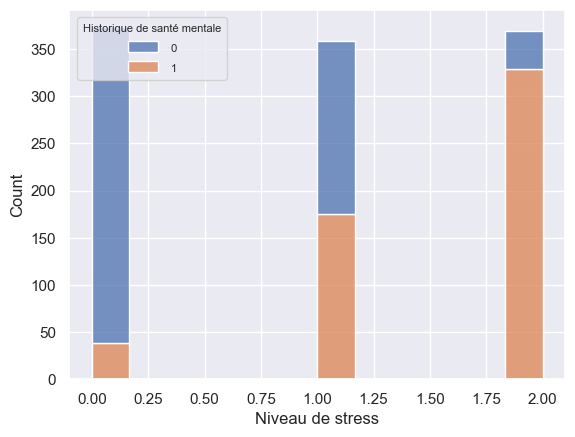

In [6]:
# Historique santé mentale
ax=sns.histplot(data=stress, x='niveau_stress', hue='historique_sante_mentale', multiple='stack')

ax.set(xlabel='Niveau de stress')

legend=ax.get_legend()
legend.set_title('Historique de santé mentale')
legend.get_title().set_fontsize(8)
for text in legend.get_texts():
    text.set_fontsize(8)

La valeur 1 associée à l'historique de santé mentale semble être associée à des problèmes passés, celle-ci étant davantage présente pour des niveaux de stress augmentant.

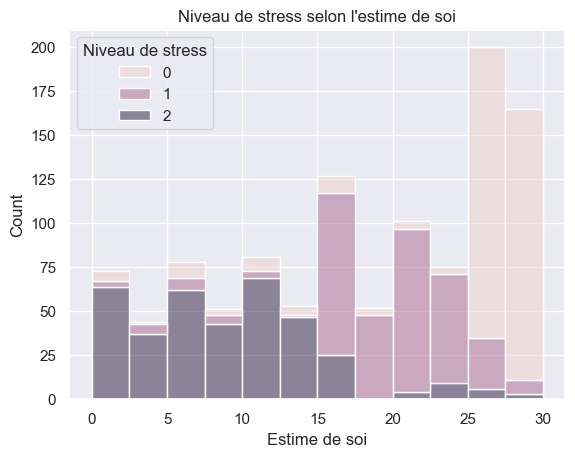

In [7]:
# Estime de soi
ax=sns.histplot(data=stress, x="estime_de_soi", hue="niveau_stress", multiple='stack',alpha=0.5)
ax.set(xlabel="Estime de soi", title="Niveau de stress selon l'estime de soi")

legend=ax.get_legend()
legend.set_title('Niveau de stress')


Une faible estime de soi semble être associée à un haut niveau de stress et réciproquement, les personnes reportant un niveau de stress de zéro coïncident avec les personnes reportant un haut score d'estime de soi.

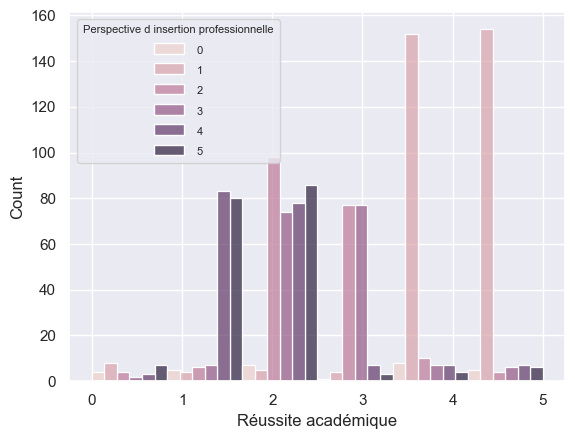

In [8]:
# On essaye de comprendre comment sont encodées les variables de réussite académique et de perspective d'insertion professionnelle

ax=sns.histplot(data=stress, x="reussite_academique", hue="perspective_insertion_professionnelle", multiple='dodge', binwidth=0.8, alpha=0.7)
ax.set(xlabel='Réussite académique')

legend=ax.get_legend()
legend.set_title('Perspective d insertion professionnelle')
legend.get_title().set_fontsize(8)
for text in legend.get_texts():
    text.set_fontsize(8)


Si l'on suppose qu'une valeur de 5 est associée à une très bonne réussite académique, de 0 à une mauvaise réussite académique, on n'observe pas de lien clair entre cette variable et la variable d'insertion professionnelle. Du moins, une réussite académique moyenne semble être associée à des niveaux divers d'insertions professionnelle et il n'apparaît pas de corrélation positive entre réussite académique et insertion professionnelle.

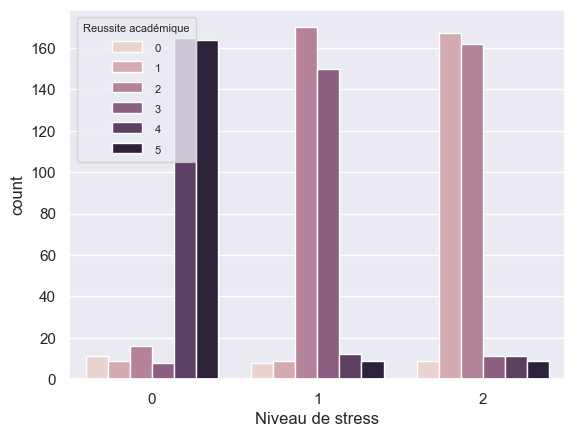

In [9]:
ax=sns.countplot(data=stress, x="niveau_stress", hue="reussite_academique", order=[0, 1, 2])

ax.set(xlabel='Niveau de stress')

legend=ax.get_legend()
legend.set_title('Reussite académique')
legend.get_title().set_fontsize(8)
for text in legend.get_texts():
    text.set_fontsize(8)


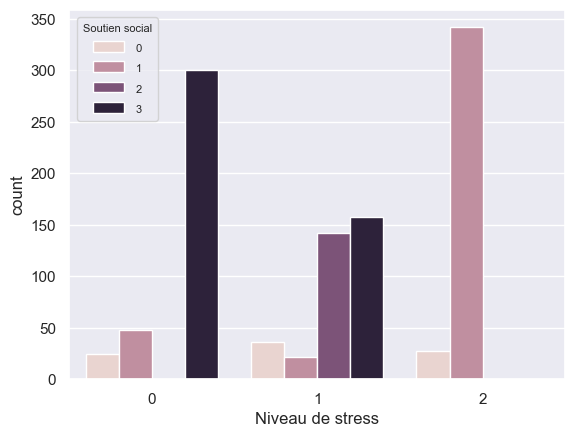

In [10]:
# Soutien social
ax=sns.countplot(data=stress, x='niveau_stress', hue='soutien_social', order=[0,1,2])
ax.set(xlabel='Niveau de stress')

legend=ax.get_legend()
legend.set_title('Soutien social')
legend.get_title().set_fontsize(8)
for text in legend.get_texts():
    text.set_fontsize(8)


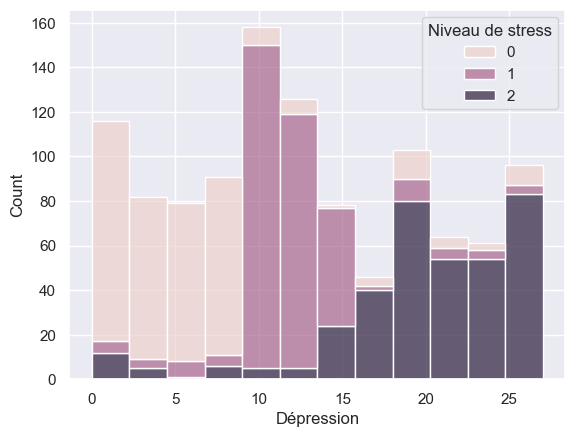

In [11]:
# Dépression
ax=sns.histplot(data=stress, x='depression', hue='niveau_stress', multiple='stack',alpha=0.7)
ax.set(xlabel='Dépression')

legend=ax.get_legend()
legend.set_title('Niveau de stress')


## Première régression logistique

On réalise une régression logistique sans pénalisation, pour avoir un premier aperçu de la performance d'un modèle simple. La variable d'intérêt (ou le label), encodant le niveau de stress, peut prendre trois valeurs 0, 1, 2. On choisit de comparer la régression multi-classes à la méthode OneVsRest qui fixe une classe de référence et concatène les deux autres afin d'effectuer une régression binaire. Etant donné que notre variable stress est encodée selon trois niveaux, trois régressions OneVsRest sont possibles.

In [7]:
# Préparation du jeu de données
X, y = stress.drop(['niveau_stress'], axis=1), stress['niveau_stress']
X=(X-X.mean())/X.std()
X.describe()

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,securite,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement
count,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03
mean,-1.356491e-16,-1.130409e-17,6.136505e-17,8.720297e-17,-7.751375e-17,2.050885e-16,-1.130409e-16,1.421085e-16,1.453383e-16,8.235836e-17,-5.167584e-17,-1.146558e-16,-1.570461e-16,1.772320e-16,1.453383e-16,6.136505e-17,-4.198662e-17,1.081963e-16,1.776357e-16,4.521636e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.808505e+00,-1.987487e+00,-9.851107e-01,-1.624879e+00,-1.779665e+00,-1.417771e+00,-1.717922e+00,-1.965882e+00,-1.994607e+00,-2.249968e+00,-1.946614e+00,-1.933884e+00,-1.960087e+00,-1.992595e+00,-1.912627e+00,-1.732139e+00,-1.795925e+00,-1.918622e+00,-1.952135e+00,-1.709565e+00
25%,-8.277218e-01,-7.576944e-01,-9.851107e-01,-8.483820e-01,-1.070121e+00,-1.417771e+00,-1.072086e+00,-5.380376e-01,-4.887266e-01,-4.629898e-01,-5.243122e-01,-5.389513e-01,-5.462539e-01,-4.725849e-01,-4.681438e-01,-1.078277e+00,-8.415689e-01,-5.153746e-01,-5.412621e-01,-1.056380e+00
50%,-1.040225e-02,1.367001e-01,-9.851107e-01,-7.188481e-02,3.489666e-01,-2.181187e-01,-1.033336e-01,1.758844e-01,2.642135e-01,-4.629898e-01,-5.243122e-01,1.585151e-01,-5.462539e-01,-4.725849e-01,-4.681438e-01,-4.244157e-01,1.127876e-01,-5.153746e-01,-1.885439e-01,2.499920e-01
75%,8.069173e-01,9.192952e-01,1.014191e+00,8.340285e-01,3.489666e-01,9.815340e-01,8.654192e-01,8.898064e-01,2.642135e-01,4.304993e-01,8.979897e-01,8.559814e-01,8.675797e-01,2.874200e-01,9.763391e-01,8.833077e-01,1.067144e+00,8.878731e-01,8.696106e-01,9.031778e-01
max,1.624237e+00,1.366492e+00,1.014191e+00,1.869358e+00,1.768055e+00,9.815340e-01,1.511254e+00,1.603728e+00,1.770094e+00,2.217477e+00,1.609141e+00,1.553448e+00,1.574496e+00,1.807430e+00,1.698581e+00,1.537169e+00,1.067144e+00,1.589497e+00,1.575047e+00,1.556364e+00


In [10]:
# Préparation des sets d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # Vérification des tailles des jeux de données

print("Distribution originale :")
print(y.value_counts(normalize=True))

print("\nDistribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

# Modèles
model_multinom=LogisticRegression(penalty=None, max_iter=1000, random_state=RANDOM_STATE)
model_multinom.fit(X_train, y_train)

model_ovr=OneVsRestClassifier(LogisticRegression(penalty=None, max_iter=1000, random_state=RANDOM_STATE))
model_ovr.fit(X_train, y_train)

(880, 20) (220, 20) (880,) (220,)
Distribution originale :
niveau_stress
0    0.339091
2    0.335455
1    0.325455
Name: proportion, dtype: float64

Distribution train :
niveau_stress
0    0.339773
2    0.335227
1    0.325000
Name: proportion, dtype: float64

Distribution test :
niveau_stress
0    0.336364
2    0.336364
1    0.327273
Name: proportion, dtype: float64


,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,verbose,0
,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [11]:
def df_coef(model):
    if hasattr(model, 'estimators_'): # Pour gérer le modèle OneVsRest, qui induit un modèle par classe
        
        feature_names = model.feature_names_in_
        classes = model.classes_
        
        data = []
        class_labels = []
        
        for i, estimator in enumerate(model.estimators_):
            coef = estimator.coef_[0] 
            data.append(coef)
            class_labels.append(classes[i])
            
        df = pd.DataFrame(
            data,
            columns=feature_names,
            index=class_labels
        )
        return df
    
    return pd.DataFrame(
    model.coef_,
    columns=model.feature_names_in_,
    index=model.classes_
)


coef_multiclass = df_coef(model_multinom)
coef_ovr = df_coef(model_ovr)

In [12]:
coef_multiclass

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,securite,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement
0,-0.041761,0.173868,0.267869,-0.074105,-0.230103,0.594785,0.140162,-0.063832,-0.112678,-0.02037,0.159834,0.346028,0.379544,-0.393089,0.196549,-0.026949,1.286463,-0.125211,-0.212472,-0.068059
1,0.133522,0.277649,-0.378604,-0.097787,-0.083287,-4.669630,0.066507,-0.025545,-0.074914,-0.00124,0.015134,-0.261776,-0.048368,0.319739,-0.388200,0.086421,-1.793401,-0.085803,0.108206,-0.162304
2,-0.091761,-0.451517,0.110735,0.171893,0.313390,4.074845,-0.206669,0.089377,0.187592,0.02161,-0.174968,-0.084253,-0.331176,0.073350,0.191651,-0.059472,0.506938,0.211015,0.104267,0.230363


On retrouve ci-dessus les coefficients de la régression logistique multiclasse associées aux variables pour pour chacune des classes $0, 1, 2$. Les résultats de la régression OneVsRest ci-dessous, eux correspondent aux coefficients que l'on obtient lorsque la classe $i\in\{0,1,2\}$ est prise comme référence et que les deux autres classes sont concaténées comme contrepartie. Il s'agit de coefficients dans chacun des trois cas à une régression pour un problème de classification binaire.

In [13]:
coef_ovr

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,securite,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement
0,-0.090310,0.403816,0.372546,-0.185803,-0.417060,3.529104,0.276235,-0.120899,-0.197456,-0.035474,0.295659,0.538521,0.650496,-0.633949,0.233370,-0.076848,1.898543,-0.290689,-0.343130,-0.198705
1,0.209257,0.500505,-0.663183,-0.163720,-0.181301,-6.211529,0.065843,-0.063745,-0.095844,-0.008503,0.003343,-0.586516,-0.115621,0.553295,-0.864417,0.151354,-3.683207,-0.241569,0.162133,-0.452541
2,-0.110783,-0.669806,0.145243,0.254812,0.469787,7.627876,-0.322830,0.134118,0.331807,-0.004372,-0.229178,-0.179601,-0.492673,0.153365,0.246481,-0.078159,0.740746,0.322536,0.196598,0.337368


In [14]:
def evaluate_classifier(model, X_test, y_test, average="weighted", show_confusion=True):
    """
    Évalue un modèle de classification sklearn (binaire ou multiclasses).
    Retourne un dictionnaire contenant : la prédiction de la classe, la prediction de la probabilité P(Y=1|X), l'accuracy, la précision et le recall.
    Si show_confusion=True : affiche la matrice de confusion.
    """

    y_pred = model.predict(X_test)
    y_pred_proba = None
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)

    # Métriques
    accuracy = model.score(X_test, y_test)
    precision = precision_score(y_test, y_pred, average=average)
    recall = recall_score(y_test, y_pred, average=average)

    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")

    # Matrice de confusion
    if show_confusion:
        labels = model.classes_ if hasattr(model, "classes_") else None
        cm = confusion_matrix(y_test, y_pred, labels=labels)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=labels
        )
        disp.plot()
        plt.grid(False)
        plt.show()

    return {
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": cm if show_confusion else None
    }


Accuracy : 0.877
Precision: 0.878
Recall   : 0.877


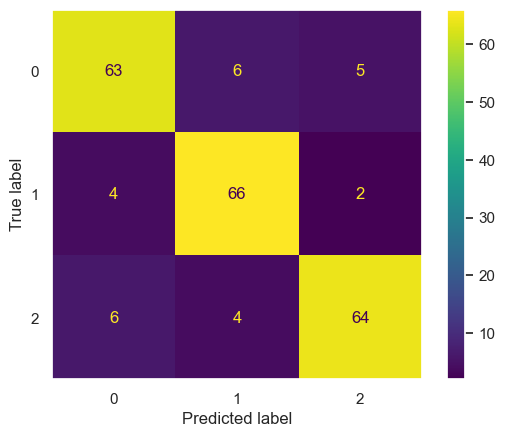

In [15]:
evaluate_multinom = evaluate_classifier(model_multinom, X_test, y_test, "weighted", True)

Accuracy : 0.877
Precision: 0.878
Recall   : 0.877


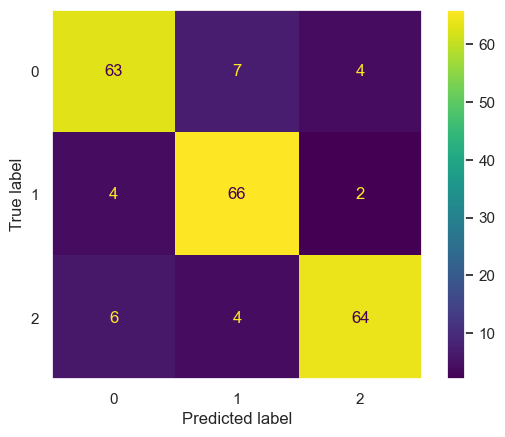

In [16]:
evaluate_ovr = evaluate_classifier(model_ovr, X_test, y_test, "weighted", True)

In [17]:
def compute_roc_curves(y_true_bin, y_pred_proba, n_classes, method_name):
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        # ROC pour la classe i
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Courbe moyenne macro
    fpr["macro"] = np.linspace(0, 1, 100)
    tpr["macro"] = np.zeros(100)
    
    for i in range(n_classes):
        tpr["macro"] += np.interp(fpr["macro"], fpr[i], tpr[i])
    tpr["macro"] /= n_classes
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    return fpr, tpr, roc_auc

In [18]:
y_pred_proba_multinom = evaluate_multinom["y_pred_proba"]
y_pred_proba_ovr = evaluate_ovr["y_pred_proba"]

# Labels binaires pour la courbe ROC
n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

fpr_m, tpr_m, auc_m = compute_roc_curves(y_test_bin, y_pred_proba_multinom, n_classes, "Multinomial")
fpr_o, tpr_o, auc_o = compute_roc_curves(y_test_bin, y_pred_proba_ovr, n_classes, "OneVsRest")

On compare d'abord classe par classe les résultats des deux types de régressions, multiclasse et OneVsRest.

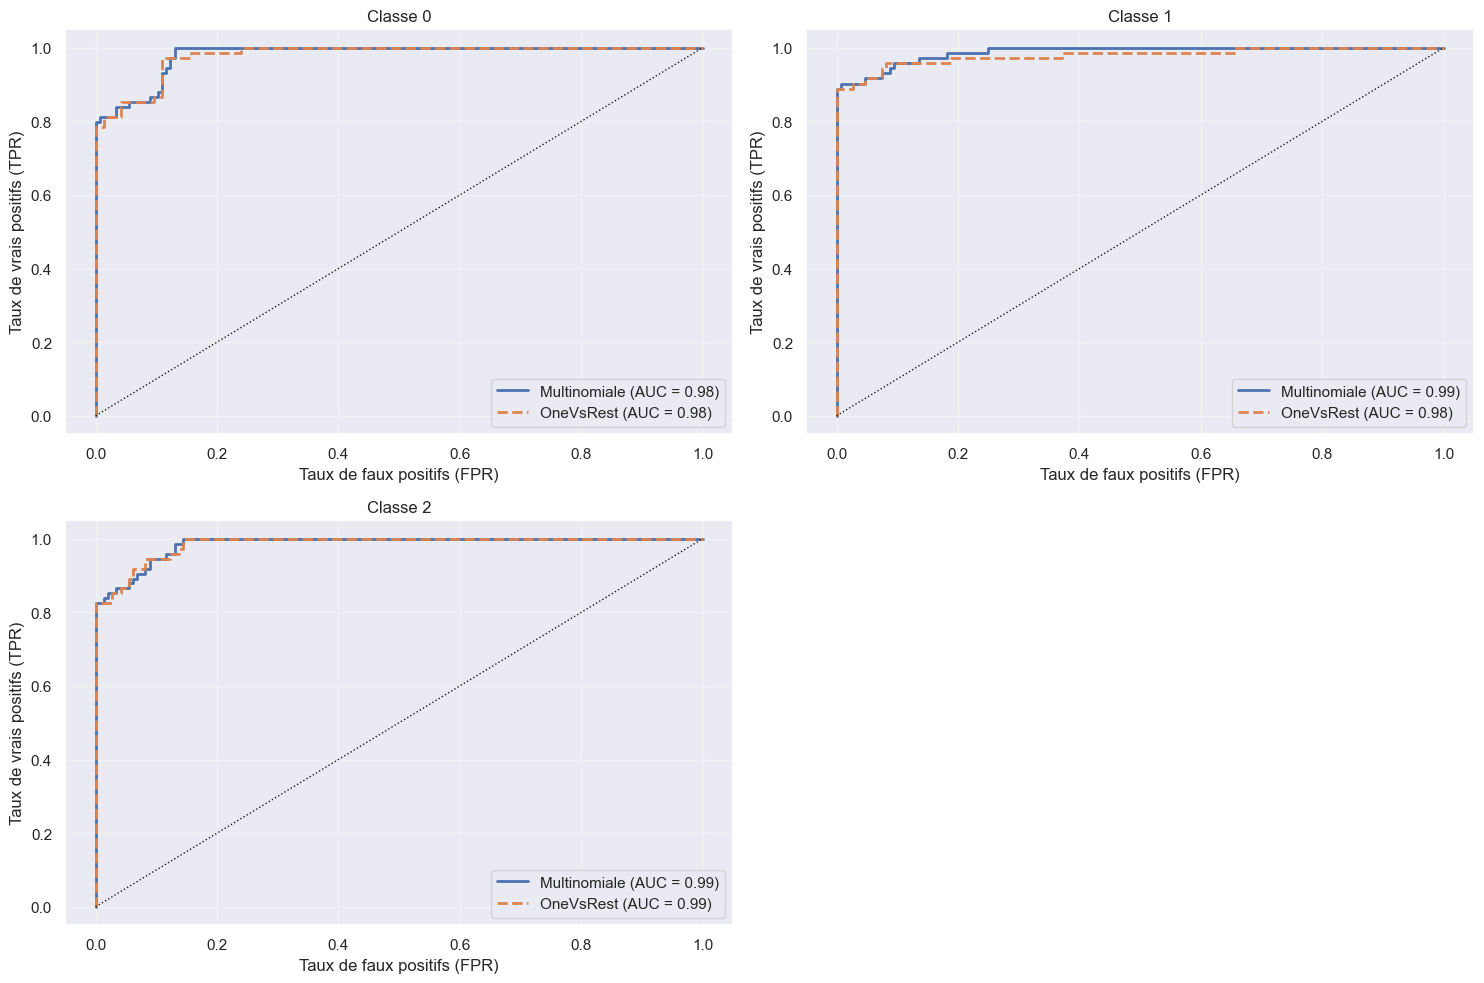

In [19]:
n_classes = len(auc_m) - 1  # On exclut la clé "macro"
cols = 2
rows = (n_classes + 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  

for i in range(n_classes):
    ax = axes[i]
    
    # Courbe multiclasse
    ax.plot(fpr_m[i], tpr_m[i], label=f'Multinomiale (AUC = {auc_m[i]:0.2f})', linewidth=2)
    
    # Courbe OneVsRest
    ax.plot(fpr_o[i], tpr_o[i], label=f'OneVsRest (AUC = {auc_o[i]:0.2f})', linewidth=2, linestyle='--')
    
    # Diagonale
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    
    ax.set_title(f'Classe {i}')
    ax.set_xlabel('Taux de faux positifs (FPR)')
    ax.set_ylabel('Taux de vrais positifs (TPR)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

# Masquer les subplots vides
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Les deux méthodes de régressions fournissent des résultats équivalents, les courbes sont superposées, il n'y en n'a pas une très clairement au dessus de l'autre dans chacun des trois cas.

On affiche ensuite les ROC-curve pour comparer les résultats des différentes classes, méthode par méthode.

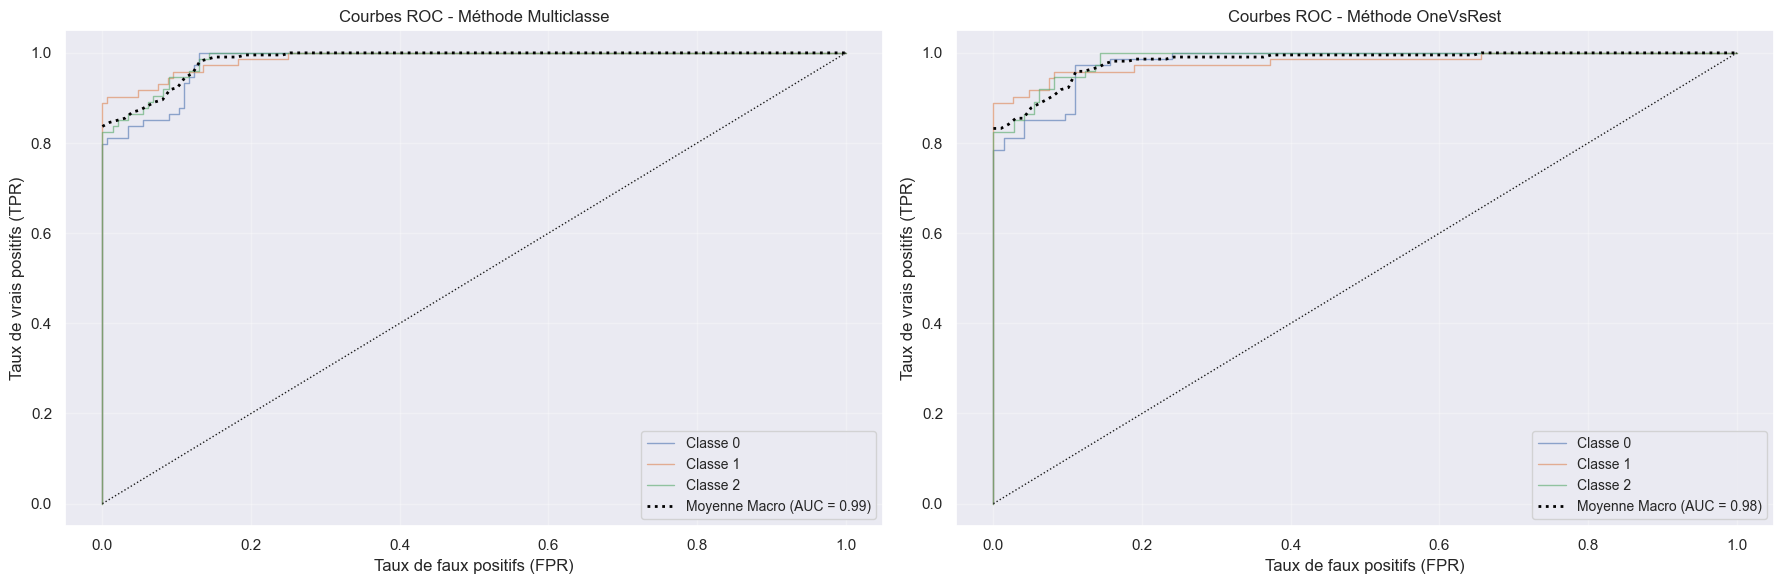

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Méthode multiclasse
for i in range(n_classes):
    ax1.plot(fpr_m[i], tpr_m[i], linewidth=1, alpha=0.6, label=f'Classe {i}')
    
ax1.plot(fpr_m["macro"], tpr_m["macro"], 
         label=f'Moyenne Macro (AUC = {auc_m["macro"]:0.2f})', 
         color='black', linestyle=':', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k:', linewidth=1)
ax1.set_title('Courbes ROC - Méthode Multiclasse')
ax1.set_xlabel('Taux de faux positifs (FPR)')
ax1.set_ylabel('Taux de vrais positifs (TPR)')
ax1.legend(loc='lower right', fontsize='small')
ax1.grid(alpha=0.3)

# Méthode OneVsRest
for i in range(n_classes):
    ax2.plot(fpr_o[i], tpr_o[i], linewidth=1, alpha=0.6, label=f'Classe {i}')

ax2.plot(fpr_o["macro"], tpr_o["macro"], 
         label=f'Moyenne Macro (AUC = {auc_o["macro"]:0.2f})', 
         color='black', linestyle=':', linewidth=2)

ax2.plot([0, 1], [0, 1], 'k:', linewidth=1)
ax2.set_title('Courbes ROC - Méthode OneVsRest')
ax2.set_xlabel('Taux de faux positifs (FPR)')
ax2.set_ylabel('Taux de vrais positifs (TPR)')
ax2.legend(loc='lower right', fontsize='small')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les résultats des prédictions sont pour les deux méthodes, les meilleurs s'agissant de la classe 1 et les moins bons s'agissant de la classe 0.

### Régression Lasso (pénalisation l1)

Les résultats de la régression logistique avec toutes les variables et sans pénalisation sont très bons. Cependant, il peut être intéressant de rechercher un modèle plus parcimonieux, n'incluant que les variables ayant la plus grande influence sur le niveau de stress. On effectue donc une régression logistique avec pénalisation l1 (Lasso), pour mettre directement les variables les moins informatives à zéro.<br>
La fonction *LogisticRegression* ne permet pas de combiner une pénalisation l1 avec une approche multi-classe où l'on compare chacune des classes avec le solver *liblinear*. On adopte donc la stratégie '*one vs the rest*', qui prend une valeur de la variable 'niveau_stress' comme référence. On a vu précédemment que cette stratégie, dans le cas sans pénalisation, fournissait des résultats semblables à la méthode multiclasse.

In [21]:
C_l=0.01
model_lasso=OneVsRestClassifier(LogisticRegression(penalty='l1', C=C_l, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE))
model_lasso.fit(X_train, y_train)

,estimator,LogisticRegre...r='liblinear')
,n_jobs,None
,verbose,0
,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [22]:
df_coef_lasso = df_coef(model_lasso)

vars_non_zero = (df_coef_lasso != 0).any(axis=0)
nb_vars_non_zero = vars_non_zero.sum()

print("======= Résultats sur l'ensemble des trois régressions =======")
print("Nombre de variables non nulles :", nb_vars_non_zero)
print("Nombre total de variables autres que celle reliée au stress: ", stress.shape[1]-1)
print("Variables sélectionnées : ", df_coef_lasso.columns[vars_non_zero])
print("Variables mises de côte : ", df_coef_lasso.columns[~vars_non_zero])
print("\n")

print("======= Résultats détaillés par régression (OneVsRest) =======\n")

for i, row in df_coef_lasso.iterrows():
    print(f"--- Régression pour la classe : {i} ---")
    
    vars_non_zero_i = row != 0
    nb_vars_non_zero_i = vars_non_zero_i.sum()
    print("Nombre de variables non nulles :", nb_vars_non_zero_i)
    selected_vars = vars_non_zero[vars_non_zero_i].index.tolist()
    rejected_vars = vars_non_zero[~vars_non_zero_i].index.tolist()
    print("Variables sélectionnées : ", selected_vars)
    print("Variables mises de côte : ", rejected_vars)
    print("\n")


======= Résultats sur l'ensemble des trois régressions =======
Nombre de variables non nulles : 14
Nombre total de variables autres que celle reliée au stress:  20
Variables sélectionnées :  Index(['niveau_anxiete', 'estime_de_soi', 'depression', 'maux_de_tete',
       'tension_arterielle', 'qualite_sommeil', 'securite',
       'besoins_elementaires', 'reussite_academique', 'relation_prof_etudiant',
       'perspective_insertion_professionnelle', 'pression_des_paires',
       'activites_extrascolaires', 'harcelement'],
      dtype='object')
Variables mises de côte :  Index(['historique_sante_mentale', 'problem_respiratoire', 'niveau_bruit',
       'conditions_vie', 'charge_travail', 'soutien_social'],
      dtype='object')


======= Résultats détaillés par régression (OneVsRest) =======

--- Régression pour la classe : 0 ---
Nombre de variables non nulles : 6
Variables sélectionnées :  ['niveau_anxiete', 'qualite_sommeil', 'securite', 'besoins_elementaires', 'reussite_academique', 'rel

In [23]:
df_coef_lasso

,niveau_anxiete,estime_de_soi,historique_sante_mentale,depression,maux_de_tete,tension_arterielle,qualite_sommeil,problem_respiratoire,niveau_bruit,conditions_vie,securite,besoins_elementaires,reussite_academique,charge_travail,relation_prof_etudiant,perspective_insertion_professionnelle,soutien_social,pression_des_paires,activites_extrascolaires,harcelement
0,-0.136208,0.000000,0.0,0.00000,0.000000,0.000000,0.146307,0.0,0.0,0.0,0.280639,0.339282,0.3565,0.0,0.148095,0.000000,0.0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.0,0.00000,0.000000,-1.025928,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0000,0.0,-0.172641,0.000000,0.0,0.000000,0.000000,0.000000
2,0.000000,-0.340922,0.0,0.06138,0.088674,0.510733,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0000,0.0,0.000000,0.019242,0.0,0.260706,0.120921,0.186764


Accuracy : 0.886
Precision: 0.896
Recall   : 0.886


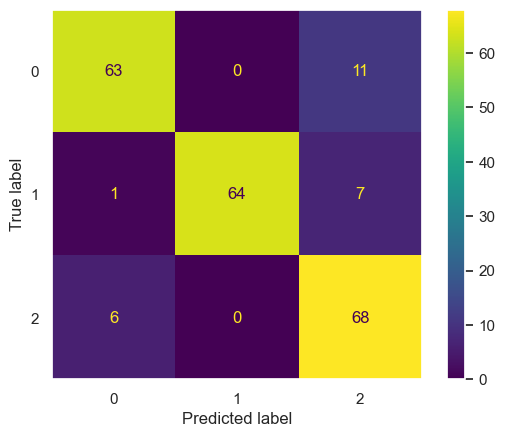

In [24]:
evaluate_lasso = evaluate_classifier(model_lasso, X_test, y_test, "weighted", True)

On améliore très légèrement les performances du modèle, en comparaison avec la régression non pénalisée, avec une précision passée de $0.877$ à $0.886$. 

In [25]:
y_pred_proba_lasso = evaluate_lasso["y_pred_proba"]
y_pred_proba_ovr = evaluate_ovr["y_pred_proba"]

# Labels binaires pour la courbe ROC
n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

fpr_l, tpr_l, auc_l = compute_roc_curves(y_test_bin, y_pred_proba_lasso, n_classes, "Multinomial")
fpr_o, tpr_o, auc_o = compute_roc_curves(y_test_bin, y_pred_proba_ovr, n_classes, "OneVsRest")

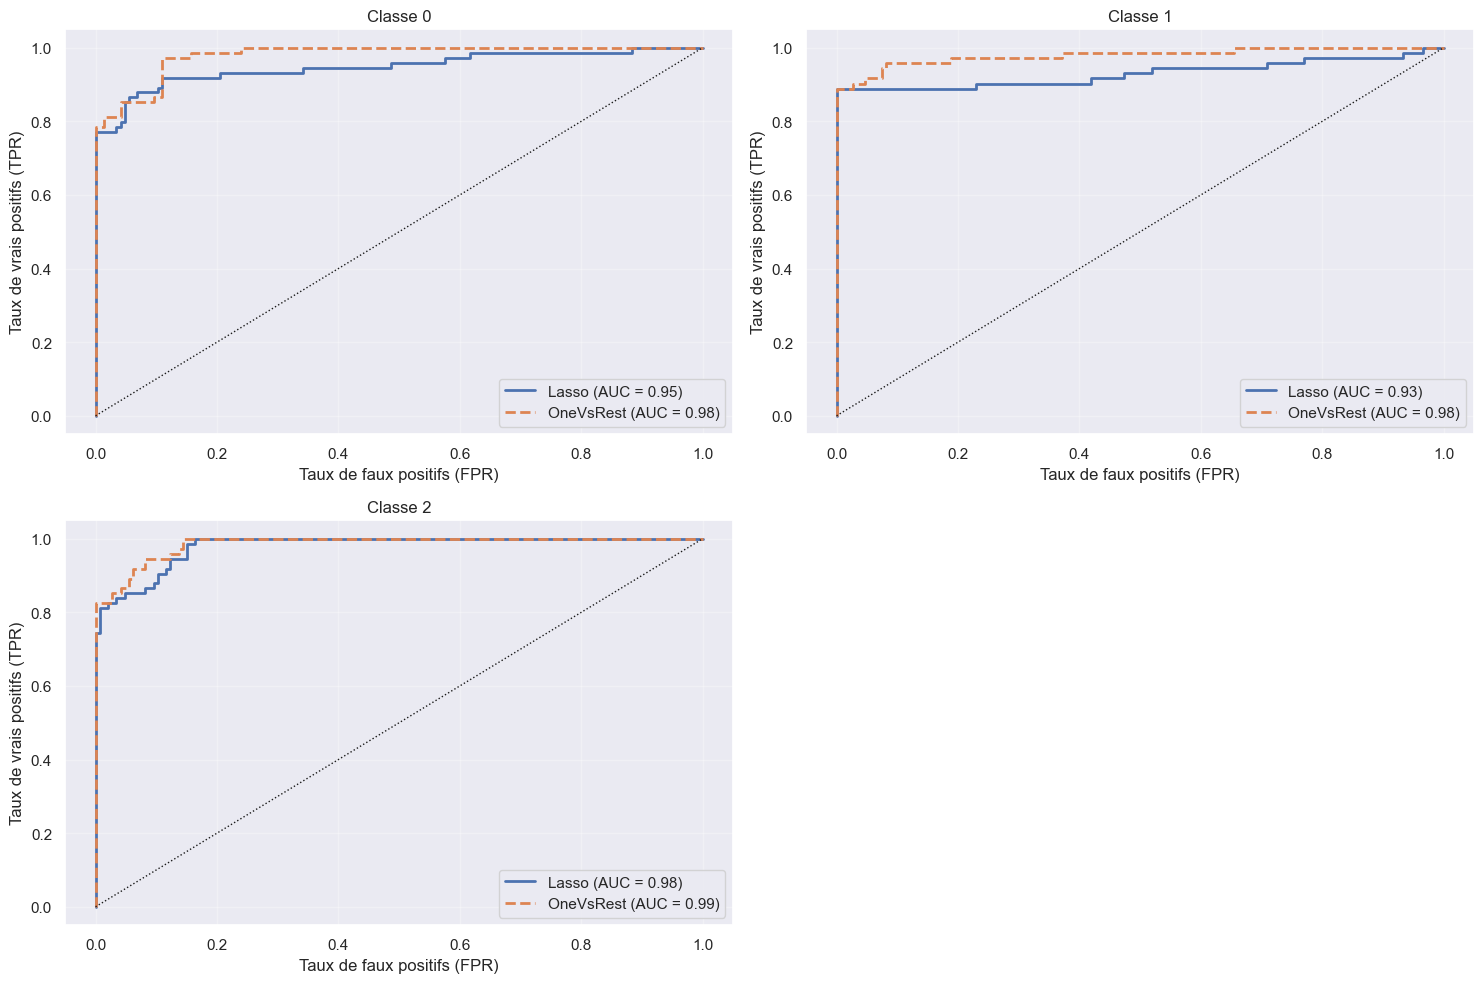

In [26]:
n_classes = len(auc_l) - 1  # On exclut la clé "macro"
cols = 2
rows = (n_classes + 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  

for i in range(n_classes):
    ax = axes[i]
    
    # Courbe Lasso
    ax.plot(fpr_l[i], tpr_l[i], label=f'Lasso (AUC = {auc_l[i]:0.2f})', linewidth=2)
    
    # Courbe OneVsRest
    ax.plot(fpr_o[i], tpr_o[i], label=f'OneVsRest (AUC = {auc_o[i]:0.2f})', linewidth=2, linestyle='--')
    
    # Diagonale
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    
    ax.set_title(f'Classe {i}')
    ax.set_xlabel('Taux de faux positifs (FPR)')
    ax.set_ylabel('Taux de vrais positifs (TPR)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

# Masquer les subplots vides
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Les résultats sont dans les trois cas meilleurs pour le modèle OneVsRest non pénalisé : la courbe ROC est au dessus de celle associée au modèle Lasso.

### Validation croisée

On réalise des régressions par validation croisée afin de choisir au mieux la constante de pénalisation $C$ associée au modèle Lasso.

In [27]:
cv_results_ovr = cross_validate(model_ovr, X_train, y_train, cv=8)
cv_results_ovr

{'fit_time': array([0.03812718, 0.02605653, 0.02680516, 0.03135896, 0.02283216,
        0.02475524, 0.02759528, 0.0267334 ]),
 'score_time': array([0.00319099, 0.00374198, 0.00399232, 0.00482416, 0.00319862,
        0.003232  , 0.00270581, 0.00397134]),
 'test_score': array([0.9       , 0.89090909, 0.89090909, 0.91818182, 0.86363636,
        0.87272727, 0.84545455, 0.86363636])}

In [28]:
cv_results_multinom = cross_validate(model_multinom, X_train, y_train, cv=8)
cv_results_multinom

{'fit_time': array([0.02769852, 0.02052307, 0.01871777, 0.01966071, 0.02144718,
        0.02315259, 0.02005649, 0.02136517]),
 'score_time': array([0.00289869, 0.00188208, 0.00173283, 0.00199175, 0.00165629,
        0.0027895 , 0.00257277, 0.00266743]),
 'test_score': array([0.9       , 0.89090909, 0.9       , 0.91818182, 0.86363636,
        0.87272727, 0.83636364, 0.86363636])}

In [29]:
cv_results_lasso = cross_validate(model_lasso, X_train, y_train, cv=8)
cv_results_lasso

{'fit_time': array([0.01843357, 0.01526928, 0.00867105, 0.01685166, 0.0135026 ,
        0.01209378, 0.01106668, 0.01997018]),
 'score_time': array([0.00458932, 0.00341201, 0.00226688, 0.00293398, 0.00261807,
        0.00256681, 0.00451779, 0.00518608]),
 'test_score': array([0.90909091, 0.87272727, 0.90909091, 0.92727273, 0.83636364,
        0.85454545, 0.85454545, 0.9       ])}

On donne les intervalles de confiance de l'*accuracy score* pour chacun des trois modèles de régression. Pour les deux premiers, sans pénalisation, les résultats sont presque égaux, avec une incertitude plus élevée pour la régression multiclasse que OneVsRest. Si l'*accuracy score* semble plus élevé pour la régression Lasso, en réalité l'intervalle de confiance est également plus grand *ie* le modèle est moins précis.

In [30]:
scores = {'Ovr' : cv_results_ovr["test_score"], 'Multinomial': cv_results_multinom["test_score"], 'Lasso': cv_results_lasso["test_score"]}
for method in scores.keys():
    print("The mean cross-validation accuracy for " f"{method}" " is: "
      f"{scores[method].mean():.3f} ± {scores[method].std():.3f}")

The mean cross-validation accuracy for Ovr is: 0.881 ± 0.022
The mean cross-validation accuracy for Multinomial is: 0.881 ± 0.025
The mean cross-validation accuracy for Lasso is: 0.883 ± 0.031


In [31]:
# Choix de la constante de pénalisation C
C_grid = np.logspace(-4, 1, 14) # Grille de valeur pour C

cv = 8
# Modèle de régression logistique avec pénalité l1 
# Validation croisée pour le choix automatique de la constante de pénalité C
model_lasso_cv = OneVsRestClassifier(LogisticRegressionCV(penalty='l1', tol=1e-3, Cs=C_grid, cv=8,
                                      solver='liblinear', scoring='roc_auc', random_state=RANDOM_STATE))

model_lasso_cv.fit(X_train, y_train)

print(f"Nombre de classes détectées : {len(model_lasso_cv.estimators_)}") # Vérification

for i, estimator in enumerate(model_lasso_cv.estimators_):

    print(f"\n--- Classe {i} (ou classe '{model_lasso_cv.classes_[i]}') ---")
    
    scores_bruts = estimator.scores_
    key = 1
    tableau_scores = scores_bruts[key]
    n_folds, n_Cs = tableau_scores.shape
    print(f"Forme détectée : {tableau_scores.shape}")
    mean_scores = np.mean(tableau_scores, axis=0)
    
    # print(f"Nombre de valeurs C : {len(mean_scores)}") # Vérification
    print(f"Meilleur score ROC-AUC moyen : {np.max(mean_scores):.4f}")
    print(f"Index du meilleur C : {np.argmax(mean_scores)}")
    print(f"Valeur du meilleur C : {C_grid[np.argmax(mean_scores)]}")
    
    # Vérification : C choisi par le modèle
    print(f"C choisi automatiquement par le modèle (C_[0]) : {estimator.C_[0]}")
    

Nombre de classes détectées : 3

--- Classe 0 (ou classe '0') ---
Forme détectée : (8, 14)
Meilleur score ROC-AUC moyen : 0.9813
Index du meilleur C : 11
Valeur du meilleur C : 1.7012542798525891
C choisi automatiquement par le modèle (C_[0]) : 1.7012542798525891

--- Classe 1 (ou classe '1') ---
Forme détectée : (8, 14)
Meilleur score ROC-AUC moyen : 0.9704
Index du meilleur C : 10
Valeur du meilleur C : 0.701703828670383
C choisi automatiquement par le modèle (C_[0]) : 0.701703828670383

--- Classe 2 (ou classe '2') ---
Forme détectée : (8, 14)
Meilleur score ROC-AUC moyen : 0.9845
Index du meilleur C : 11
Valeur du meilleur C : 1.7012542798525891
C choisi automatiquement par le modèle (C_[0]) : 1.7012542798525891


Accuracy : 0.877
Precision: 0.878
Recall   : 0.877


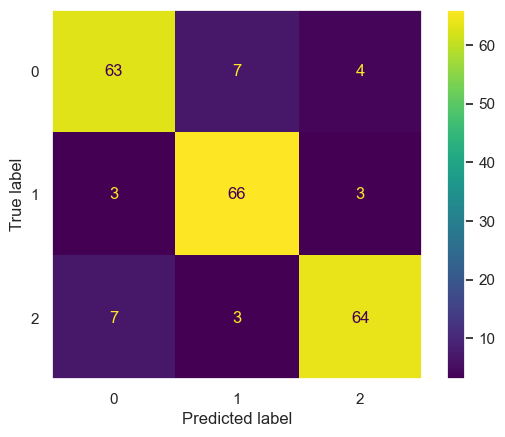

In [32]:
evaluate_lasso_cv = evaluate_classifier(model_lasso_cv, X_test, y_test, "weighted", True)

In [33]:
y_pred_proba_lasso_cv = evaluate_lasso_cv["y_pred_proba"]

# Labels binaires pour la courbe ROC
n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

fpr_lcv, tpr_lcv, auc_lcv = compute_roc_curves(y_test_bin, y_pred_proba_lasso_cv, n_classes, "Lasso cv")

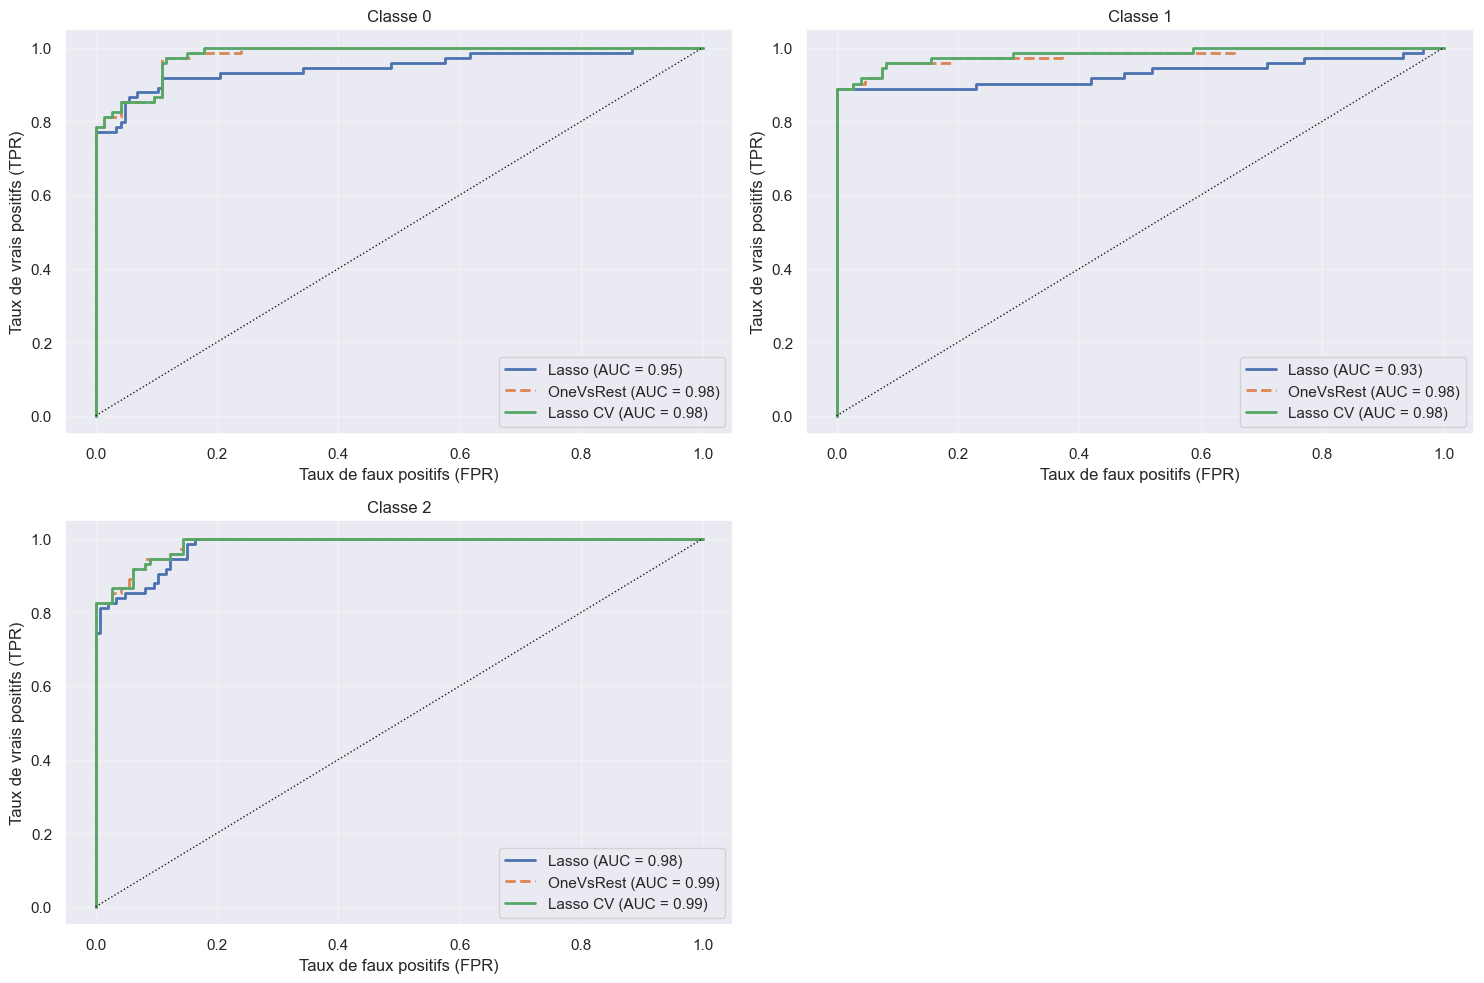

In [34]:
n_classes = len(auc_l) - 1  # On exclut la clé "macro"
cols = 2
rows = (n_classes + 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  

for i in range(n_classes):
    ax = axes[i]
    
    # Courbe Lasso
    ax.plot(fpr_l[i], tpr_l[i], label=f'Lasso (AUC = {auc_l[i]:0.2f})', linewidth=2)
    
    # Courbe OneVsRest
    ax.plot(fpr_o[i], tpr_o[i], label=f'OneVsRest (AUC = {auc_o[i]:0.2f})', linewidth=2, linestyle='--')

    # Courbe Lasso CV
    ax.plot(fpr_lcv[i], tpr_lcv[i], label=f'Lasso CV (AUC = {auc_lcv[i]:0.2f})', linewidth=2)
    
    # Diagonale
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    
    ax.set_title(f'Classe {i}')
    ax.set_xlabel('Taux de faux positifs (FPR)')
    ax.set_ylabel('Taux de vrais positifs (TPR)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

# Masquer les subplots vides
for j in range(n_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Le modèle Lasso avec constante choisie par validation croisée a un score AUC aussi bon que le modèle OneVsRest dans les trois cas. On dispose donc d'un modèle plus parcimonieux avec des performances équivalentes au modèle incluant toutes les variables explicatives.

In [35]:
AUC_lasso_cv = roc_auc_score(y_test, y_pred_proba_lasso_cv, multi_class='ovr', average='macro')
AUC_ovr = roc_auc_score(y_test, y_pred_proba_ovr, multi_class='ovr', average='macro')
AUC_lasso = roc_auc_score(y_test, y_pred_proba_lasso, multi_class='ovr', average='macro')

print(f"AUC no penalty: {AUC_ovr:.5f}")
print(f"AUC Lasso: {AUC_lasso:.5f}")
print(f"AUC Lasso-CV: {AUC_lasso_cv:.5f}")

AUC no penalty: 0.98142
AUC Lasso: 0.95279
AUC Lasso-CV: 0.98258


## Arbres de classification

In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import time as tm

In [37]:
def fit_and_predict_error(model, x_train, y_train, x_test, y_test):
    start_time = tm.time()
    model.fit(x_train, y_train)
    predict_train = model.predict(x_train)
    predict_test = model.predict(x_test)
    end_time = tm.time()

    mape_test = mape(y_test, predict_test)*100
    rmse_test = rmse(y_test, predict_test)
   
    return {'train' : predict_train, 'test' : predict_test, 
            'mape_train' : mape(y_train, predict_train)*100,
            'mape_test' : mape_test,
            'rmse_train' : rmse(y_train, predict_train), 
            'rmse_test' : rmse_test, 
            'time' : end_time-start_time}

In [38]:
def add_error(model_out, model_name, df):
    return df._append({'Model' : model_name, 
                  'MAPE test' : model_out['mape_test'], 
                  'RMSE test' : model_out['rmse_test'], 
                  'MAPE train' : model_out['mape_train'], 
                  'RMSE train' : model_out['rmse_train'], 
                  'CPU time' : model_out['time']}, ignore_index=True)

In [ ]:
# Création d'un dataframe pour stocker les erreurs des différents modèles que l'on s'apprête à tester
df_errors = pd.DataFrame()

In [ ]:
regressor_cart = DecisionTreeRegressor(random_state=RANDOM_STATE)
cart = fit_and_predict_error(regressor_cart, X_train, y_train, X_test, y_test)
df_errors = add_error(cart, 'Cart', df_errors)

In [41]:
df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.0,0.0,0.016645


Ici l'on n'impose pas de limite de profondeur à l'arbre de classification : chaque feuille contient exactement un échantillon de odnnées du train (ou plusieurs identiques). Il classifie donc parfaitement sur le train. Les résultats sur l'échantillon test sont intrigants : les deux erreurs ne sont pas du tout du même ordre de grandeur. Sans doute une division par zéro est effectuée dans le calcul du MAPE, ce qui fait exploser sa valeur. On n'est pas censés s'attendre à d'excellents résultats dans ce cas sur la partie test, étant donné que l'arbre overfit les données train.

In [42]:
df_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': regressor_cart.feature_importances_})

df_importances = df_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

df_importances

,Variable,Importance
0,reussite_academique,0.547763
1,qualite_sommeil,0.187492
2,relation_prof_etudiant,0.055462
3,besoins_elementaires,0.036855
4,estime_de_soi,0.031106
5,problem_respiratoire,0.021761
6,securite,0.019991
7,charge_travail,0.014554
8,niveau_bruit,0.014332
9,harcelement,0.012289


Pour rappel, avec le modèle de régression Lasso, on avait en regroupant les résultats des trois régressions possibles : 

Variables sélectionnées :  Index(['niveau_anxiete', 'estime_de_soi', 'depression', 'maux_de_tete',
       'tension_arterielle', 'qualite_sommeil', 'securite',
       'besoins_elementaires', 'reussite_academique', 'relation_prof_etudiant',
       'perspective_insertion_professionnelle', 'pression_des_paires',
       'activites_extrascolaires', 'harcelement'],
      dtype='object')

Variables mises de côte :  Index(['historique_sante_mentale', 'problem_respiratoire', 'niveau_bruit',
       'conditions_vie', 'charge_travail', 'soutien_social'])

On observe quelques divergences : ici la variable relative aux problèmes respiratoires est la 5e plus importante, tandis qu'elle n'était pas sélectionnée par la régression Lasso. Les activités extrascolaires et la tension artérielle ont un niveau d'importance égal à zéro selon l'arbre de classification, tandis qu'elles étaient toutes deux sélectionnées par la régression Lasso.

On choisit dans la suite de considérer un dataset 'X_S' ne conservant que les cinq premières variables par ordre d'importance données ci-dessus.

In [43]:
print(f"Profondeur actuelle de l'arbre : {regressor_cart.tree_.max_depth}")
print(f"Nombre total de nœuds : {regressor_cart.tree_.node_count}")
print(f"Nombre de feuilles (nœuds terminaux) : {regressor_cart.tree_.n_leaves}")

Profondeur actuelle de l'arbre : 13
Nombre total de nœuds : 125
Nombre de feuilles (nœuds terminaux) : 63


In [44]:
# On modifie la profondeur de l'arbre pour voir l'impact sur les performances et limiter l'overfitting
max_depth = 10 # On passe dans un premier temps de 13 à 10

# On définit un ensemble de variables semblant expliquer le mieux le niveau de stress 
variables_pertinentes = ['reussite_academique', 'qualite_sommeil', 'relation_prof_etudiant', 'besoins_elementaires', 'estime_de_soi', 'problem_respiratoire']
X_train_S = X_train[variables_pertinentes]
X_test_S = X_test[variables_pertinentes]

regressor_10 = DecisionTreeRegressor(max_depth = 10, random_state=RANDOM_STATE)
regressor_10_S = DecisionTreeRegressor(max_depth = 10, random_state=RANDOM_STATE)

cart_10 = fit_and_predict_error(regressor_10, X_train, y_train, X_test, y_test)
cart_10_S = fit_and_predict_error(regressor_10_S, X_train_S, y_train, X_test_S, y_test)

df_errors = add_error(cart_10, 'Cart, Depth 10', df_errors)
df_errors = add_error(cart_10_S, 'Cart S, Depth 10', df_errors)


In [45]:
df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987


Les deux résultats du MAPE semblent confirmer l'hypothèse d'une division par zéro. Nous ne considèrerons donc que le RMSE comme métrique d'erreur.

In [46]:
print("===== regressor_10 =====")
print('Observations par noeud', regressor_10.tree_.n_node_samples) # nb d'observations par noeud
print('Nombre de noeuds', regressor_10.tree_.node_count) # nb de noeuds
print(f"Nombre de feuilles (nœuds terminaux) : {regressor_10.tree_.n_leaves}")

print("")

print("===== regressor_10_S =====")
print('Observations par noeud', regressor_10_S.tree_.n_node_samples) # nb d'observations par noeud
print('Nombre de noeuds', regressor_10_S.tree_.node_count) # nb de noeuds
print(f"Nombre de feuilles (nœuds terminaux) : {regressor_10_S.tree_.n_leaves}")

===== regressor_10 =====
Observations par noeud [880 578 273 253 248   3   1   2 245   5   3   2   1   2  20  13   6   4
   2   7   4   2   2   3   7   3   4   3   1 305  15   1  14   6   3   3
   1   2   8 290   9   4   5   2   3 281   6   4   2 275   4   1   3 271
 267   8   6   1   5   2 259   6 253  10 243   4 302  51  41  21   2  19
  11   3   2   1   8   5   1   4   3   8   6   2   1   1  20   3   2   1
  17   7   2   1   1   5  10   7   3   1   2  10   5   3   2   5 251 249
   2   1   1]
Nombre de noeuds 111
Nombre de feuilles (nœuds terminaux) : 56

===== regressor_10_S =====
Observations par noeud [880 578 273 253   7   3   1   2   4   3   1 246 244   2   1   1  20  13
  12   9   7   1   6   4   2   1   1   2   3   2   1   1   7   5   1   4
   2   2   1   1   2 305  15   1  14   2  12   6   6   5   4   1   1 290
   4 286   8   1   7   2   1   1   5 278 251   1 250   2 248 247   5 242
   1  27   7   2   5   3   2   1   2   1   1  20  19  17   9   8   2   1
 302  51  41  21  17 

In [47]:
max_depth = 5

regressor_5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
regressor_5_S = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)

cart_5 = fit_and_predict_error(regressor_5, X_train, y_train, X_test, y_test)
cart_5_S = fit_and_predict_error(regressor_5_S, X_train_S, y_train, X_test_S, y_test)

df_errors = add_error(cart_5, 'Cart, Depth 5', df_errors)
df_errors = add_error(cart_5_S, 'Cart S, Depth 5', df_errors)

df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647


In [48]:
print("===== regressor_5 =====")
print('Observations par noeud', regressor_5.tree_.n_node_samples) # nb d'observations par noeud
print('Nombre de noeuds', regressor_5.tree_.node_count) # nb de noeuds
print(f"Nombre de feuilles (nœuds terminaux) : {regressor_5.tree_.n_leaves}")

print("")

print("===== regressor_5_S =====")
print('Observations par noeud', regressor_5_S.tree_.n_node_samples) # nb d'observations par noeud
print('Nombre de noeuds', regressor_5_S.tree_.node_count) # nb de noeuds
print(f"Nombre de feuilles (nœuds terminaux) : {regressor_5_S.tree_.n_leaves}")

===== regressor_5 =====
Observations par noeud [880 578 273 253 248   3 245   5   2   3  20  13   6   7   7   3   4 305
  15   1  14   6   8 290   9   5   4 281   6 275 302  51  41  21   2  19
  20   3  17  10   5   3   2   5 251 249   2   1   1]
Nombre de noeuds 49
Nombre de feuilles (nœuds terminaux) : 25

===== regressor_5_S =====
Observations par noeud [880 578 273 253   7   3   4 246 244   2  20  13  12   1   7   5   2 305
  15   1  14   2  12 290   4 286   8 278 302  51  41  21  17   4  20  15
   5  10   4   3   1   6   4   2 251 249   2   1   1]
Nombre de noeuds 49
Nombre de feuilles (nœuds terminaux) : 25


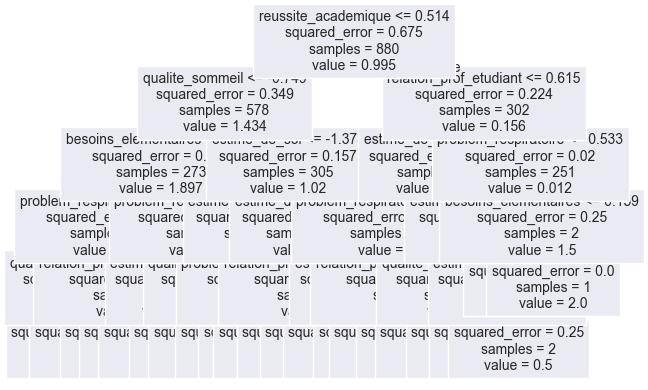

In [49]:
tree.plot_tree(regressor_5_S, fontsize=10, feature_names=X_train_S.columns.values)
plt.rcParams["figure.figsize"] = (20,10)
plt.show()

In [50]:
# Bagging

cart = DecisionTreeRegressor(max_depth=10)
bagging_S = BaggingRegressor(estimator=cart, oob_score=True, n_estimators=100, random_state=RANDOM_STATE)

bagging_small = fit_and_predict_error(bagging_S, X_train_S, y_train, X_test_S, y_test)
df_errors = add_error(bagging_small, 'Bagging Cart depth 10 S', df_errors)

bagging = BaggingRegressor(estimator=cart, oob_score=True, n_estimators=100, random_state=RANDOM_STATE)
bagging_large = fit_and_predict_error(bagging, X_train, y_train, X_test, y_test)
df_errors = add_error(bagging_large, 'Bagging Cart depth 10', df_errors)

df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674


In [51]:
# Random Forest
rf_s = RandomForestRegressor(oob_score=True, random_state=RANDOM_STATE)
rf = RandomForestRegressor(oob_score=True, random_state=RANDOM_STATE)

rf_all = fit_and_predict_error(rf, X_train, y_train, X_test, y_test)
rf_small = fit_and_predict_error(rf_s, X_train_S, y_train, X_test_S, y_test)   

df_errors = add_error(rf_small, 'Default Random Forest S', df_errors)
df_errors = add_error(rf_all, 'Default Random Forest', df_errors)

df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945


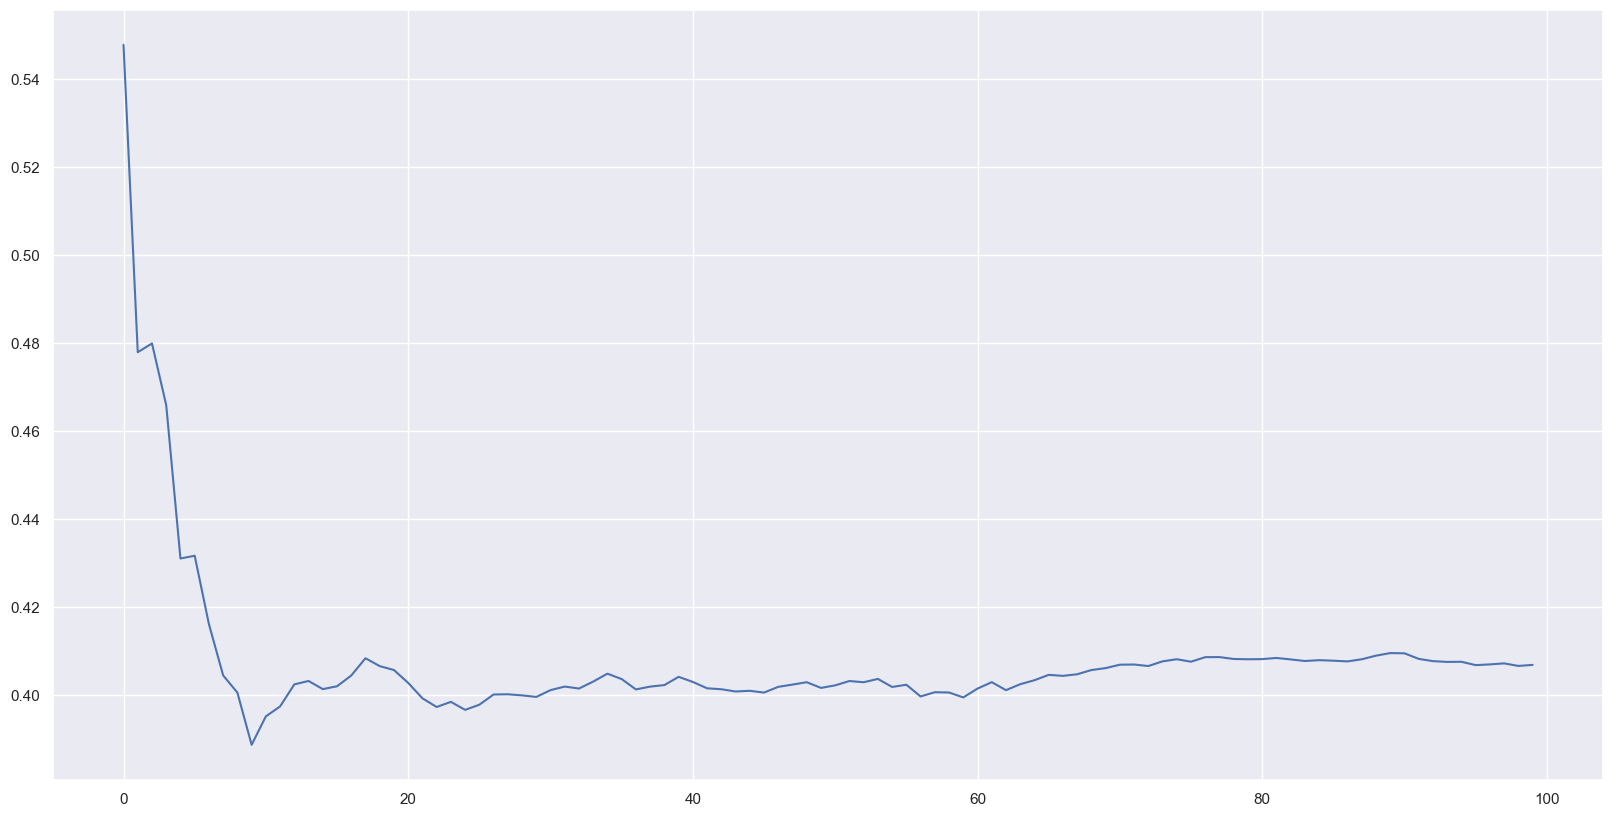

In [52]:
# Evolution de l'erreur - small
K = rf_s.n_estimators
prev_test = np.zeros((len(X_test_S), K))
errEvol = np.zeros(K)
for k in range(K):
    prev_test[:, k] = rf_s.estimators_[k].predict(X_test_S.values)
    pred_mean_k = prev_test[:, : (k+1)].mean(axis = 1)
    errEvol[k] = rmse(y_test, pred_mean_k)
plt.plot(errEvol)

L'erreur est minimale pour $5\leq n\leq10$ arbres dans la forêt. Seulement, cette dernière varie en fait très fortement jusqu'à $n \simeq 20-25$. Nous évaluons donc le modèle pour deux forêts de $n=25$ et $n=60$ arbres respectivement. Dans le dernier cas, on choisit un nombre d'arbres suffisamment important pour être certains d'être dans une zone où l'erreur s'est stabilisée autour d'une valeur minimale ($0.4$ environ). On diminue également le nombre d'arbres fixé par défaut à $100$. Cependant, pour les mêmes arguments, on aurait aussi bien pu prendre comme comparaison de $25$, $n=40$ ou $50$ arbres.

In [53]:
rf_S_60 = RandomForestRegressor(max_features= "sqrt", n_estimators= 60, oob_score=True, random_state=RANDOM_STATE)
rf_S_25 = RandomForestRegressor(max_features= "sqrt", n_estimators= 25, oob_score=True, random_state=RANDOM_STATE)

rf_small_60 = fit_and_predict_error(rf_S_60, X_train_S, y_train, X_test_S, y_test)
df_errors = add_error(rf_small_60, 'Random Forest 60 sqrt S', df_errors)

rf_small_25 = fit_and_predict_error(rf_S_25, X_train_S, y_train, X_test_S, y_test)
df_errors = add_error(rf_small_25, 'Random Forest 25 sqrt S', df_errors)


df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


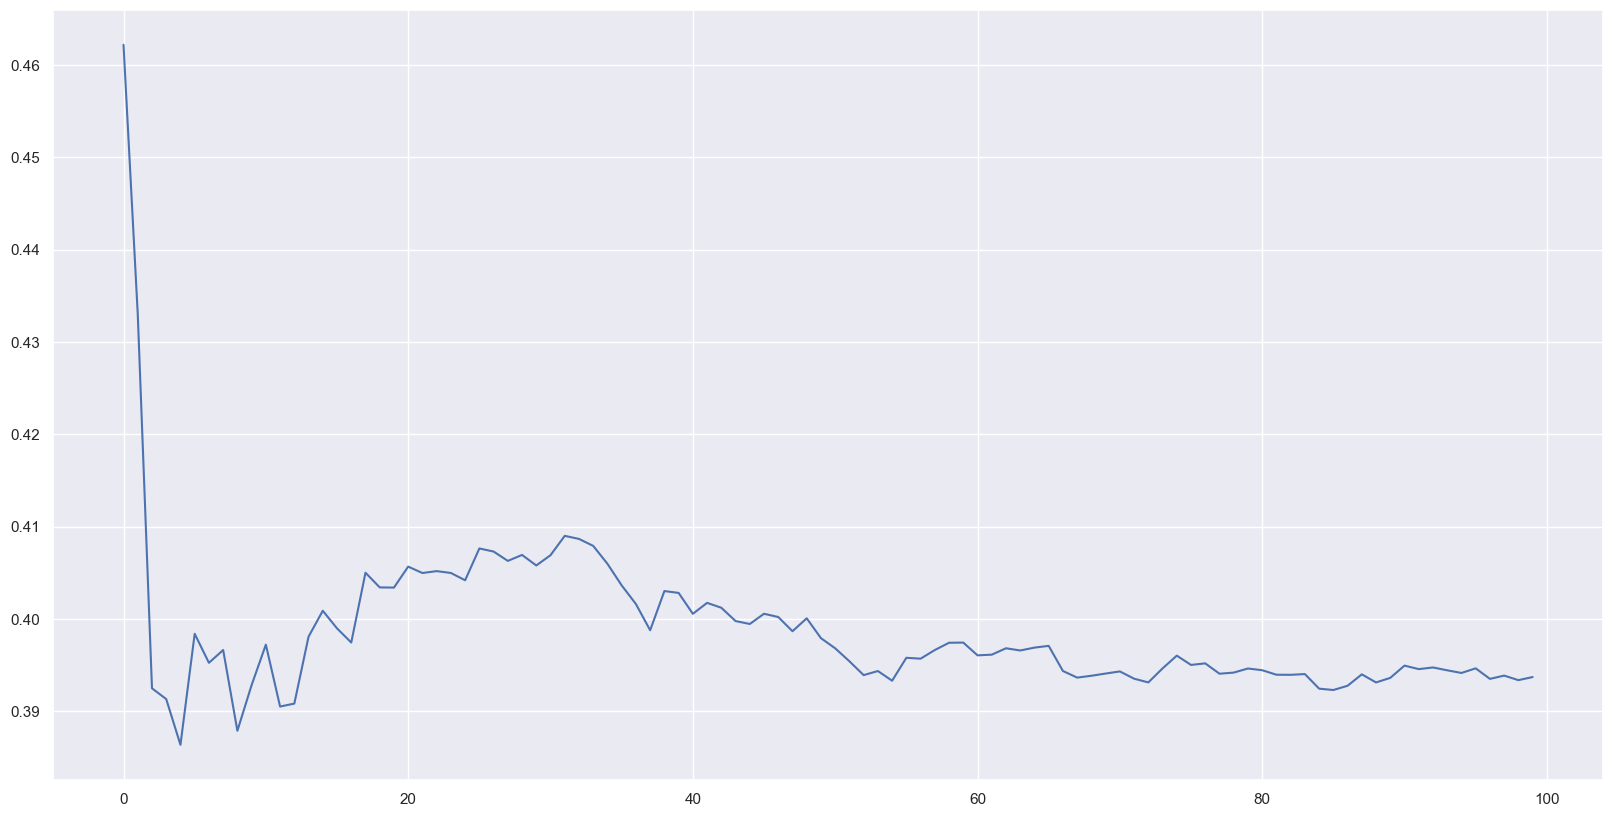

In [54]:
# Evolution de l'erreur - tout 

K = rf.n_estimators
prev_test = np.zeros((len(X_test), K))
errEvol = np.zeros(K)
for k in range(K):
    prev_test[:, k] = rf.estimators_[k].predict(X_test.values)
    pred_mean_k = prev_test[:, : (k+1)].mean(axis = 1)
    errEvol[k] = rmse(y_test, pred_mean_k)
plt.plot(errEvol)

De même, on observe que l'erreur chute au delà de $n \geq 5$ arbres et se stabilise pour $n \geq 25$ arbres environ. Afin de comparer les résultats on estime aussi les erreurs pour deux forêts de $60$ et $25$ arbres.

In [55]:
rf_60 = RandomForestRegressor(max_features= "sqrt", n_estimators= 60, oob_score=True, random_state=RANDOM_STATE)
rf_25 = RandomForestRegressor(max_features= "sqrt", n_estimators= 25, oob_score=True, random_state=RANDOM_STATE)

rf_all_60 = fit_and_predict_error(rf_60, X_train, y_train, X_test, y_test)
df_errors = add_error(rf_all_60, 'Random Forest 60 sqrt', df_errors)

rf_all_25 = fit_and_predict_error(rf_25, X_train, y_train, X_test, y_test)
df_errors = add_error(rf_all_25, 'Random Forest 25 sqrt', df_errors)

df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


La forêt de $60$ arbres donne de meilleurs résultats que la forêt de $25$ arbres dans les deux cas. Néanmoins la différence n'est pas flagrante si l'on considère les modèles S sur le jeu de données restreint.

On teste à présent l'approche par Gradient Boosting. Il s'agit dans un premier temps de fixer les hyperparamètres. Dans le cas où l'on ne considère que cinq variables explicatives, on observe qu'un arbre de profondeur $5$ présente une erreur bien moins importante sur les données de test que pour l'arbre de profondeur $10$. Pour le cas où l'on considère toutes les variables, les deux erreurs sont proches, celle pour l'arbre de profondeur $10$ étant légèrement inférieure à celle de l'arbre de profondeur $5$. On choisit donc *max_depth=5* pour comparer les deux cas. On garde le nombre d'arbres/d'itérations à sa valeur par défaut *n_estimators = 100*. De même, on conserve *learning_rate=0.1* pour limiter l'overfitting.

In [ ]:
# Boosting
gb_s = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, max_depth=5)
gb = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, max_depth=5)

gb_small = fit_and_predict_error(gb_s, X_train_S, y_train, X_test_S, y_test)
df_errors = add_error(gb_small, 'Gradient Boosting S n=100', df_errors)

gb_all = fit_and_predict_error(gb, X_train, y_train, X_test, y_test)
df_errors = add_error(gb_all, 'Gradient Boosting n=100', df_errors)

df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


In [60]:
def gradient_boosting(params, X_train, X_test, y_train, y_test, s):
    
    gbc = GradientBoostingRegressor(random_state=RANDOM_STATE)

    random_search = RandomizedSearchCV(estimator=gbc, param_distributions=params,
    n_iter=50, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=RANDOM_STATE)

    random_search.fit(X_train, y_train)

    best_gb = random_search.best_estimator_

    gb_result = fit_and_predict_error(best_gb, X_train, y_train, X_test, y_test)
    
    if s :
        best_name = f"GB Optimisé S (n={random_search.best_params_['n_estimators']}, lr={random_search.best_params_['learning_rate']:.2f})"
    else : 
        best_name = f"GB Optimisé (n={random_search.best_params_['n_estimators']}, lr={random_search.best_params_['learning_rate']:.2f})"

    return best_name, gb_result
        

La prochaine fois que j'exécute le code, réécrire avant les résultats avec la fonction

In [61]:
# Sélection des hyperparamètres avec RandomizedSearchCV

param_dist = {
 "n_estimators": randint(100, 500),
 "learning_rate": uniform(0.01, 0.2),
 "max_depth": randint(5, 10),
 "subsample": uniform(0.6, 0.4)
 }

best_name, gb_result = gradient_boosting(param_dist, X_train, X_test, y_train, y_test, False)

df_errors = add_error(gb_result, best_name, df_errors)

df_errors

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


In [62]:
best_name_S, gb_result_S = gradient_boosting(param_dist, X_train_S, X_test_S, y_train, y_test, True)

df_errors = add_error(gb_result_S, best_name_S, df_errors)

df_errors

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


In [65]:
# Comparaison avec la partie d'avant 
lasso = fit_and_predict_error(model_lasso, X_train, y_train, X_test, y_test)
lasso_S = fit_and_predict_error(model_lasso, X_train_S, y_train, X_test_S, y_test)
lasso_cv = fit_and_predict_error(model_lasso_cv, X_train, y_train, X_test, y_test)
lasso_cv_S = fit_and_predict_error(model_lasso_cv, X_train_S, y_train, X_test_S, y_test)

df_errors = add_error(lasso, "Lasso", df_errors)
df_errors = add_error(lasso_S, "Lasso S", df_errors)
df_errors = add_error(lasso_cv, "Lasso CV", df_errors)
df_errors = add_error(lasso_cv_S, "Lasso CV S", df_errors)

In [66]:
df_errors

,Model,MAPE test,RMSE test,MAPE train,RMSE train,CPU time
0,Cart,3.480054e+16,0.495434,0.000000e+00,0.000000,0.016645
1,"Cart, Depth 10",3.195989e+16,0.483146,1.746345e+15,0.091471,0.008551
2,"Cart S, Depth 10",4.159006e+16,0.574561,1.128015e+15,0.093516,0.004987
3,"Cart, Depth 5",3.911615e+16,0.494777,1.312860e+16,0.244892,0.008007
4,"Cart S, Depth 5",3.275259e+16,0.472454,1.422986e+16,0.259733,0.004647
5,Bagging Cart depth 10 S,3.295335e+16,0.409043,1.049255e+16,0.148164,0.272376
6,Bagging Cart depth 10,3.539262e+16,0.393214,1.064340e+16,0.139842,0.355674
7,Default Random Forest S,3.275345e+16,0.406910,9.575267e+15,0.137692,0.184231
8,Default Random Forest,3.504619e+16,0.393700,1.012286e+16,0.135167,0.286945
9,Random Forest 60 sqrt S,3.459583e+16,0.407268,9.936920e+15,0.137415,0.115691


## Réseaux de neurones

On souhaite construire et entraîner un petit réseau de neurones sur nos données. On propose une structure avec une seule couche cachée, avec pour fonction d'activation `ReLU`. On effectue une descente de gradient stochastique lors de l'entraînement, en partitionnant nos données en mini-batchs.

In [67]:
import os
import copy 
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

In [68]:
# Rappel
print(X.shape, y.shape)

(1100, 20) (1100,)


In [69]:
class data():
    def __init__(self, X_train, y_train):
        super().__init__()
        self.X = torch.from_numpy(X_train.to_numpy()).type(torch.FloatTensor)
        self.y = torch.from_numpy(y_train.to_numpy()).type(torch.LongTensor)
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
    def __len__(self):
        return self.len

In [70]:
data_train = data(X_train, y_train)
data_test = data(X_test, y_test)

In [71]:
INPUT_NUM = data_train.X.shape[1] # Taille de notre jeu de données
HIDDEN_NUM = 10 # Choisi arbitrairement (dans l'idéal il faudrait tester plusieurs structures différentes)
OUTPUT_NUM = len(data_train.y.unique()) # Nombre de classes que l'on souhaite prédire

class MultiClassNet(nn.Module):
    def __init__(self, INPUT_NUM, HIDDEN_NUM, OUTPUT_NUM):
        super().__init__()
        self.flatten = nn.Flatten()
        self.lin1 = nn.Linear(INPUT_NUM, HIDDEN_NUM)
        self.relu = nn.ReLU()
        self.lin2 = nn.Linear(HIDDEN_NUM, OUTPUT_NUM)

    def forward(self, x):
        x = self.flatten(x)
        x = self.lin1(x)
        x = self.relu(x)
        x = self.lin2(x)
        # x = self.log_softmax(x)
        return x

In [73]:
def training (model, optimizer, epochs, batch_size=32) :
    
    criterion = nn.CrossEntropyLoss()
    loss_train, accuracy_train, accuracy_test = [], [], [] 

    n_train = len(data_train.y)
    n_test = len(data_test.y)   
    n_iters = n_train // batch_size

    with tqdm(range(epochs), unit="epoch") as tepoch:
        for epoch in tepoch:

            model.train() 
            running_loss = 0
            idx = torch.randperm(n_train)

            for k in range(n_iters):

                batch = idx[k*batch_size: min((k+1)*batch_size, n_train)]
                x_batch, y_batch = data_train.X[batch], data_train.y[batch] 
      
                optimizer.zero_grad()
                scores = model(x_batch)
                loss = criterion(scores, y_batch)
                loss.backward()
                optimizer.step()
        
                running_loss += loss.item()
    
            running_loss /= n_iters
            loss_train.append(running_loss)
            model.eval()
    
            with torch.no_grad():
                scores = model(data_train.X)
                correct = (scores.max(axis=1).indices.flatten() == data_train.y).sum().item()
                accuracy_train.append(correct / n_train)
                scores = model(data_test.X)
                correct = (scores.max(axis=1).indices.flatten() == data_test.y).sum().item()
                accuracy_test.append(correct / n_test)
            tepoch.set_postfix(loss=loss_train[-1], accuracy=accuracy_train[-1], accuracy_test=accuracy_test[-1])

    return { "loss": loss_train, "accuracy_train": accuracy_train, "accuracy_test": accuracy_test }
        

In [74]:
model = MultiClassNet(INPUT_NUM=INPUT_NUM, HIDDEN_NUM=HIDDEN_NUM, OUTPUT_NUM=OUTPUT_NUM)
state_init = copy.deepcopy(model.state_dict())

lr = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
model.load_state_dict(copy.deepcopy(state_init))

epochs = 50

results_model = training(model, optimizer, epochs, batch_size=32)

100%|██████████| 50/50 [00:00<00:00, 53.81epoch/s, accuracy=0.958, accuracy_test=0.891, loss=0.119]
